In [1]:
from glob import glob
import random
from PIL import Image
import torch
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

In [2]:
pretrained_weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1

In [3]:
model = mobilenet_v3_small(weights=pretrained_weights)
model.eval()
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [4]:
image_paths = glob('../1_image_classification/dog_cat_dataset/train/cat/*') + \
    glob('../1_image_classification/dog_cat_dataset/train/dog/*')
len(image_paths), image_paths[:3]

(8007,
 ['../1_image_classification/dog_cat_dataset/train/cat/cat.2718.jpg',
  '../1_image_classification/dog_cat_dataset/train/cat/cat.3406.jpg',
  '../1_image_classification/dog_cat_dataset/train/cat/cat.1211.jpg'])

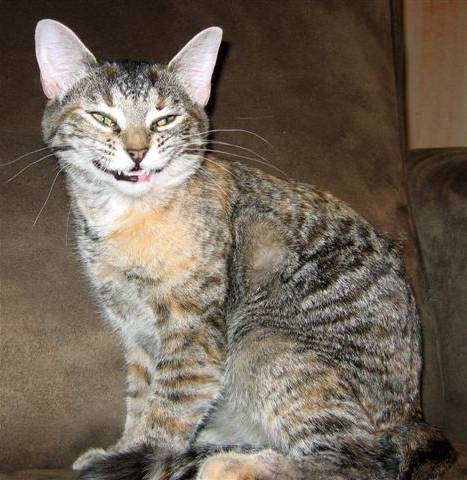

In [5]:
image = Image.open(image_paths[0])
image

In [6]:
# Initialize the Weight Transforms
preprocess = pretrained_weights.transforms()

# Apply it to the input image
image_transformed = preprocess(image)

In [7]:
image_transformed.shape, image_transformed

(torch.Size([3, 224, 224]),
 tensor([[[-1.3987, -1.3987, -1.1760,  ..., -0.1999, -0.2513, -0.2684],
          [-1.3815, -1.3644, -1.2788,  ..., -0.2342, -0.2513, -0.2513],
          [-1.3987, -1.3815, -1.2959,  ..., -0.2513, -0.2684, -0.2513],
          ...,
          [-0.6109, -0.6281, -0.6109,  ..., -1.7925, -1.8610, -1.7925],
          [-0.7137, -0.6794, -0.5082,  ..., -1.9295, -1.9809, -1.9809],
          [-0.5596, -0.5253, -0.5596,  ..., -1.9295, -1.9980, -1.9980]],
 
         [[-1.4755, -1.4580, -1.2129,  ..., -0.6877, -0.7227, -0.7402],
          [-1.4580, -1.4230, -1.3354,  ..., -0.6702, -0.6877, -0.6877],
          [-1.4755, -1.4580, -1.3704,  ..., -0.6527, -0.6702, -0.6527],
          ...,
          [-0.7577, -0.7752, -0.7577,  ..., -1.7906, -1.8606, -1.7731],
          [-0.8627, -0.8277, -0.6527,  ..., -1.9307, -1.9832, -1.9657],
          [-0.7052, -0.6702, -0.7052,  ..., -1.9307, -2.0007, -1.9832]],
 
         [[-1.4036, -1.2816, -0.9330,  ..., -0.8633, -0.8981, -0.9156],


In [8]:
us_image_transformed = image_transformed.unsqueeze(0)
us_image_transformed.shape

torch.Size([1, 3, 224, 224])

In [9]:
output = model(us_image_transformed)
output.shape

torch.Size([1, 1000])

In [10]:
# Dataloader

In [11]:
output_list, label_list, path_list = [], [], []
random.shuffle(image_paths)
for idx, path in enumerate(image_paths):
    label_list.append(path.split('/')[-2])
    path_list.append(path)
    image = Image.open(path)
    image_transformed = preprocess(image)
    output = model(image_transformed.unsqueeze(0))
    output_list.append(output.detach().numpy()[0])

    if idx == 200:
        break

In [12]:
# label_list

In [13]:
# output_list[1]

In [14]:
from sklearn.cluster import DBSCAN, KMeans

In [15]:
kmeans_model = KMeans(2)
kmeans_model

KMeans(n_clusters=2)

In [16]:
kmeans_model.fit(output_list)

/Users/minhnguyenhuu/WORK/minhhuunguyen.github.io/docs/lecture_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/minhnguyenhuu/WORK/minhhuunguyen.github.io/docs/lecture_env/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


KMeans(n_clusters=2)

In [20]:
kmeans_model.labels_[13:26]

array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1], dtype=int32)

In [21]:
print(label_list[13:26])

['dog', 'cat', 'cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'cat']


In [25]:
import os

In [28]:
path_dict = {
    1: [],
    0: []
}
for path, pred in zip(path_list, kmeans_model.labels_):
    os.makedirs(f'{pred}', exist_ok=True)
    os.system(f'cp {path} {pred}')
    path_dict[pred].append(path)

In [23]:
path_dict[1]

['../1_image_classification/dog_cat_dataset/train/cat/cat.2266.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2669.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.1783.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2779.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.448.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.1071.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.505.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.1755.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2944.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2774.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2857.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.1835.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2787.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2303.jpg',
 '../1_image_classification/dog_cat_

In [24]:
path_dict[0]

['../1_image_classification/dog_cat_dataset/train/dog/dog.3034.jpg',
 '../1_image_classification/dog_cat_dataset/train/cat/cat.2006.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.1470.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.409.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.1738.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.1767.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3059.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.1577.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3649.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3263.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.1511.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3096.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3.jpg',
 '../1_image_classification/dog_cat_dataset/train/dog/dog.3242.jpg',
 '../1_image_classification/dog_cat_da